In [1]:
import polars as pl
from tcrtrifold.tcrdock_utils import (
    dgeom_ndarr_from_dgeom_series,
    mn_distr_from_dgeom_ndarr,
    mn_distance_from,
    un_cossin_embed,
)
from tcrtrifold.utils import filter_to_cog_thresh, FORMAT_ANTIGEN_COLS, FORMAT_TCR_COLS


iedb_II_conf = pl.read_parquet(
    "../../data/iedb_II/triad/iedb_II_triad.conf_af3.parquet"
)
iedb_II_tcrdock = pl.read_parquet(
    "../../data/iedb_II/triad/staged/iedb_II_triad.af3_tcrdock.parquet"
)

iedb_II = iedb_II_conf.join(
    iedb_II_tcrdock.select("pred_dgeom_4", "job_name").with_columns(
        pl.col("pred_dgeom_4").struct.unnest()
    ),
    on="job_name",
    how="inner",
)

template_dgeom = pl.read_csv(
    "../../data/pdb/raw/ternary_templates_v2.tsv", separator="\t"
).with_columns(
    pl.struct(
        **{
            k: pl.col(k)
            for k in [
                "d",
                "torsion",
                "mhc_unit_x_is_negative",
                "tcr_unit_y",
                "tcr_unit_z",
                "tcr_unit_x_is_negative",
                "mhc_unit_y",
                "mhc_unit_z",
            ]
        }
    ).alias("dgeom"),
    pl.when(pl.col("mhc_class") == 1)
    .then(pl.lit("I"))
    .otherwise(pl.lit("II"))
    .alias("mhc_class"),
)

class_II_t_dgeom = dgeom_ndarr_from_dgeom_series(
    template_dgeom.filter(pl.col("mhc_class") == "II").select("dgeom").to_series()
)

class_II_distr = mn_distr_from_dgeom_ndarr(class_II_t_dgeom)

_, iedb_II_p_dgeom = mn_distance_from(
    dgeom_ndarr_from_dgeom_series(iedb_II.select("pred_dgeom_4").to_series()),
    *class_II_distr,
)

iedb_II = iedb_II.with_columns(pl.Series(name="p_dgeom", values=iedb_II_p_dgeom))

iedb_II = iedb_II.explode("references")

assay_type = pl.read_parquet("../../data/iedb_meta/assay_type.parquet")

iedb_II_best_pos = (
    iedb_II.explode("receptor_id")
    .join(assay_type, on="receptor_id")
    .filter(
        pl.col("assay_type").is_in(
            ["x-ray crystallography", "surface plasmon resonance (SPR)"]
        )
    )
    .select(pl.exclude("receptor_id", "assay_type"))
    .unique()
)

iedb_II_neg = (
    iedb_II.filter(~pl.col("cognate"))
    .join(iedb_II_best_pos.select(FORMAT_ANTIGEN_COLS).unique(), on=FORMAT_ANTIGEN_COLS)
    .select(pl.exclude("receptor_id"))
)

iedb_II_best = pl.concat([iedb_II_best_pos, iedb_II_neg])


cresta_conf = pl.read_parquet("../../data/cresta/triad/cresta_triad.conf_af3.parquet")
cresta_tcrdock = pl.read_parquet(
    "../../data/cresta/triad/staged/cresta_triad.af3_tcrdock.parquet"
)
cresta = cresta_conf.join(
    cresta_tcrdock.select("pred_dgeom_4", "job_name").with_columns(
        pl.col("pred_dgeom_4").struct.unnest()
    ),
    on="job_name",
    how="inner",
)

_, cresta_p_dgeom = mn_distance_from(
    dgeom_ndarr_from_dgeom_series(cresta.select("pred_dgeom_4").to_series()),
    *class_II_distr,
)

cresta = cresta.with_columns(pl.Series(name="p_dgeom", values=cresta_p_dgeom))

In [2]:
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import numpy as np


def violin_abs_feature(df, featname: str, invert=False):
    """
    Violin plot of |feature| for cognates vs noncognates.
    Annotates:
      - absolute feature threshold T above which no noncognates are found
      - # and % of cognates with |feature| > T
    """
    # Pull data from Polars or Pandas
    if hasattr(df, "select"):  # Polars
        dat = df.select([featname, "cognate"]).to_numpy()
    else:  # Pandas/DataFrame-like
        dat = df[[featname, "cognate"]].to_numpy()

    x = dat[:, 0].astype(float)
    y = dat[:, 1].astype(bool)  # True = cognate

    # Drop NaNs / infs in the feature
    finite = np.isfinite(x)
    x = x[finite]
    y = y[finite]

    x_abs = np.abs(x)
    cog_vals = x_abs[y]
    non_vals = x_abs[~y]

    # Threshold T: "absolute feature value above which no noncognates are found"
    if non_vals.size > 0:
        if invert:
            T = float(np.min(non_vals))
        else:
            T = float(np.max(non_vals))
    else:
        T = np.nan  # no noncognates present; threshold undefined

    # Cognate counts above threshold
    if np.isfinite(T) and cog_vals.size > 0:
        if invert:
            n_cog_above = int(np.sum(cog_vals < T))
        else:
            n_cog_above = int(np.sum(cog_vals > T))
        n_cog_total = int(cog_vals.size)
        pct_cog_above = (n_cog_above / n_cog_total) * 100.0
    else:
        n_cog_above = 0
        n_cog_total = int(cog_vals.size)
        pct_cog_above = np.nan

    fig, ax = plt.subplots(figsize=(6, 6))

    parts = ax.violinplot(
        [non_vals, cog_vals],
        positions=[0, 1],
        showmeans=False,
        showmedians=True,
        widths=0.8,
    )

    # Basic cosmetics
    ax.set_xticks([0, 1], labels=["noncognate", "cognate"])
    ax.set_ylabel(f"{featname}")
    ax.set_title(f"Distribution of {featname}")

    # Horizontal line at T
    if np.isfinite(T):
        ax.axhline(T, linestyle="--", linewidth=1, alpha=0.8)
        ax.text(
            0.02,
            0.98,
            f"Threshold feature value = {T:.3g}\n"
            f"Cognates > T: {n_cog_above}/{n_cog_total}"
            + (f" ({pct_cog_above:.1f}%)" if np.isfinite(pct_cog_above) else ""),
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize="small",
            bbox=dict(boxstyle="round,pad=0.3", alpha=0.25),
        )

    # Expand y-limits a bit to show the annotation line clearly
    ymin, ymax = ax.get_ylim()
    if np.isfinite(T):
        ymax = max(ymax, T * 1.05 if T > 0 else 1.0)
    ax.set_ylim(ymin, ymax)

    return fig, ax

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Distribution of tcr_mhc_contacts'}, ylabel='tcr_mhc_contacts'>)

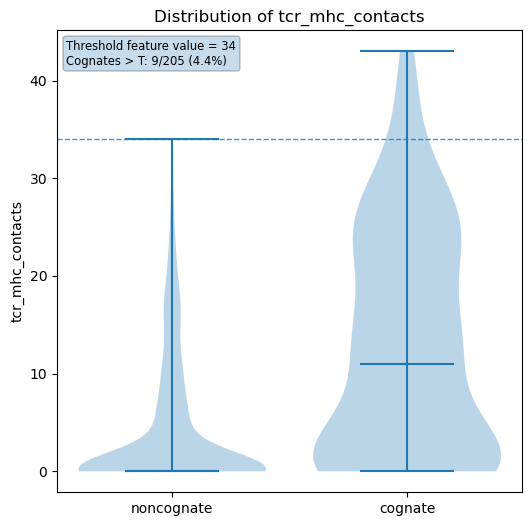

In [6]:
violin_abs_feature(cresta, "tcr_mhc_contacts", invert=False)


(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Distribution of tcr_mhc_contacts'}, ylabel='tcr_mhc_contacts'>)

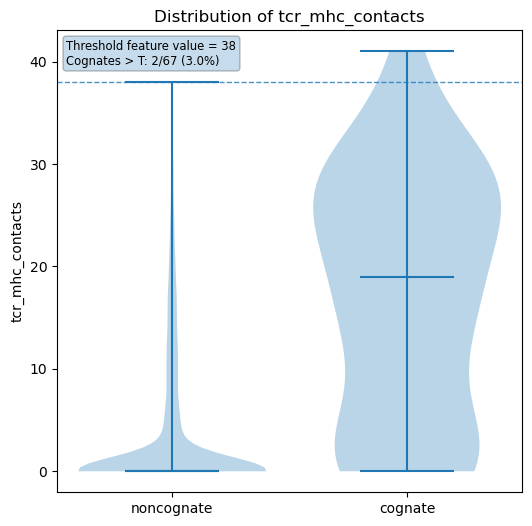

In [5]:
violin_abs_feature(iedb_II_best, "tcr_mhc_contacts", invert=False)
